# Tarea 3: Análisis Espectral de Audio
**Curso:** IMT2220 - Cálculo para Ciencia de Datos  
**Estudiantes:** Benjamin Pardo Albornoz, Zhongzhe Cheng

---

## Parte 1: Señal y Espectro

### 1. Carga del archivo de audio, procesamiento y visualización

En esta sección vamos a realizar los siguientes pasos:
1. Importar las librerías necesarias (`numpy` y `matplotlib`).
2. Cargar el archivo `'audio.wav'` usando `scipy.io.wavfile`.
3. Quedarnos únicamente con el canal izquierdo en caso de que sea estéreo (verificando la forma de la matriz de datos).
4. Normalizar la señal al rango $[-1, 1]$ dividiendo por el valor máximo absoluto teórico según el tipo de datos original (`int16`, lo que corresponde a $32768$).
5. Graficar la amplitud de la señal en función del tiempo (en segundos, calculando el eje X usando la frecuencia de muestreo).

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1. Cargar el archivo de audio
samplerate, data = wavfile.read('audio.wav')

print("Información básica del audio:")
print(f"- Frecuencia de muestreo (sample rate): {samplerate} Hz")
print(f"- Dimensiones de los datos: {data.shape}")
print(f"- Tipo de datos original (dtype): {data.dtype}")

Información básica del audio:
- Frecuencia de muestreo (sample rate): 44100 Hz
- Dimensiones de los datos: (3131392, 2)
- Tipo de datos original (dtype): int16


In [142]:
# 2. Selección del canal izquierdo (si es estéreo)
if len(data.shape) > 1 and data.shape[1] > 1:
    signal = data[:, 0]  # El canal izquierdo es la primera columna
    print("El audio es estéreo. Se ha extraído el canal izquierdo.")
else:
    signal = data
    print("El audio es mono. Se utiliza la señal completa.")

# 3. Normalización al rango [-1, 1]
# Como el tipo de datos es int16, el valor máximo absoluto teórico es 32768 (2^15)
if data.dtype == np.int16:
    max_theoretical = 32768
else:
    max_theoretical = 1.0

signal_norm = signal / max_theoretical
print(f"Señal normalizada. Rango: [{signal_norm.min()}, {signal_norm.max()}]")

El audio es estéreo. Se ha extraído el canal izquierdo.
Señal normalizada. Rango: [-0.389007568359375, 0.328338623046875]


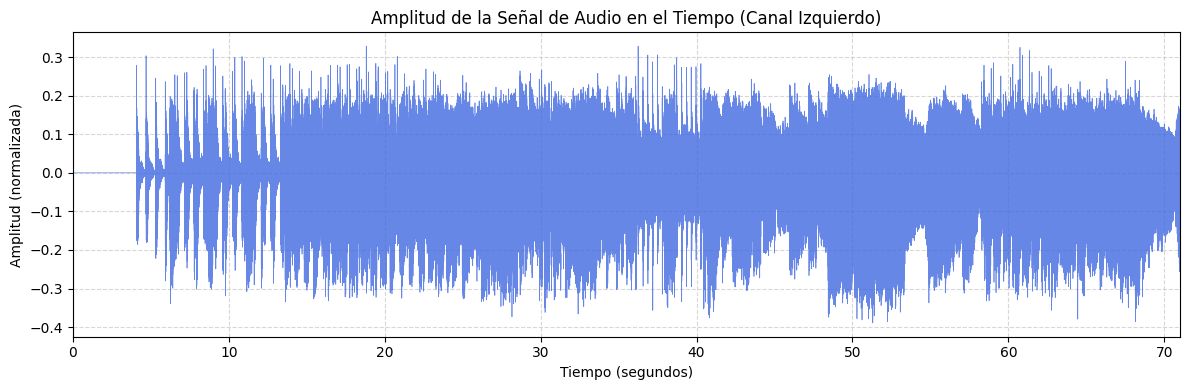

In [143]:
# 4. Creación del eje de tiempo (en segundos) y visualización
num_samples = len(signal_norm)
duration = num_samples / samplerate
time = np.linspace(0, duration, num_samples, endpoint=False)

# Graficar la amplitud en función del tiempo
plt.figure(figsize=(12, 4))
plt.plot(time, signal_norm, color='royalblue', alpha=0.8, linewidth=0.5)
plt.title("Amplitud de la Señal de Audio en el Tiempo (Canal Izquierdo)", fontsize=12)
plt.xlabel("Tiempo (segundos)", fontsize=10)
plt.ylabel("Amplitud (normalizada)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, duration)
plt.tight_layout()
plt.show()

### 2. Cálculo de la FFT y espectro de magnitud

En esta celda vamos a:
1. Calcular la transformada de Fourier rápida para señales reales (`numpy.fft.rfft`).
2. Graficar el espectro de magnitud en función de la frecuencia (en Hz).
3. Identificar y etiquetar las 5 frecuencias más dominantes de la señal.

Las 5 frecuencias más dominantes son:
1. Frecuencia: 293.20 Hz (Magnitud: 13504.06)
2. Frecuencia: 440.99 Hz (Magnitud: 10267.32)
3. Frecuencia: 439.35 Hz (Magnitud: 9735.34)
4. Frecuencia: 467.65 Hz (Magnitud: 7398.17)
5. Frecuencia: 588.17 Hz (Magnitud: 5828.84)


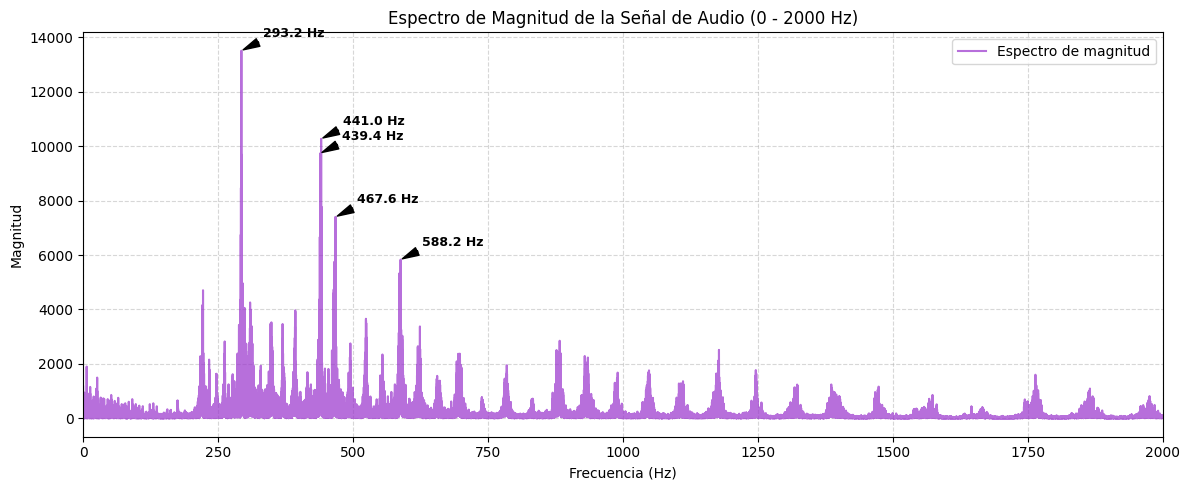

In [144]:
from scipy.signal import find_peaks

# 1. Calcular la FFT para señales reales
fft_vals = np.fft.rfft(signal_norm)
fft_freqs = np.fft.rfftfreq(num_samples, d=1/samplerate)
magnitudes = np.abs(fft_vals)

# 2. Encontrar las 5 frecuencias más dominantes usando picos aislados
# Buscamos máximos locales con una distancia mínima entre sí para evitar seleccionar bins adyacentes del mismo pico
peaks, _ = find_peaks(magnitudes, distance=100)
top_peaks = peaks[np.argsort(magnitudes[peaks])][::-1][:5]

top_freqs = fft_freqs[top_peaks]
top_mags = magnitudes[top_peaks]

print("Las 5 frecuencias más dominantes son:")
for i, (freq, mag) in enumerate(zip(top_freqs, top_mags), 1):
    print(f"{i}. Frecuencia: {freq:.2f} Hz (Magnitud: {mag:.2f})")

# 3. Graficar el espectro de magnitud
plt.figure(figsize=(12, 5))
plt.plot(fft_freqs, magnitudes, color='darkorchid', alpha=0.7, label='Espectro de magnitud')

# Etiquetar las frecuencias dominantes en el gráfico
for freq, mag in zip(top_freqs, top_mags):
    plt.annotate(f"{freq:.1f} Hz", xy=(freq, mag), xytext=(freq + 40, mag + 500),
                 arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
                 fontsize=9, fontweight='bold')

plt.title("Espectro de Magnitud de la Señal de Audio (0 - 2000 Hz)", fontsize=12)
plt.xlabel("Frecuencia (Hz)", fontsize=10)
plt.ylabel("Magnitud", fontsize=10)
plt.xlim(0, 2000)  # Hacemos zoom en el rango de interés (bajas-medias frecuencias)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

---  
## Parte 2: Filtros

### 3. Filtro pasa-bajos

A partir del espectro de magnitud anterior, observamos que los picos principales están todos bajo los $600$ Hz. Para remover el brillo y las componentes agudas, definimos una frecuencia de corte $f_c = 400$ Hz. Esto conservará las frecuencias de la base fundamental ($222.12$ Hz y $293.20$ Hz) pero eliminará las notas de mayor frecuencia (como $440.99$ Hz, $467.65$ Hz y $588.17$ Hz) y sus armónicos.

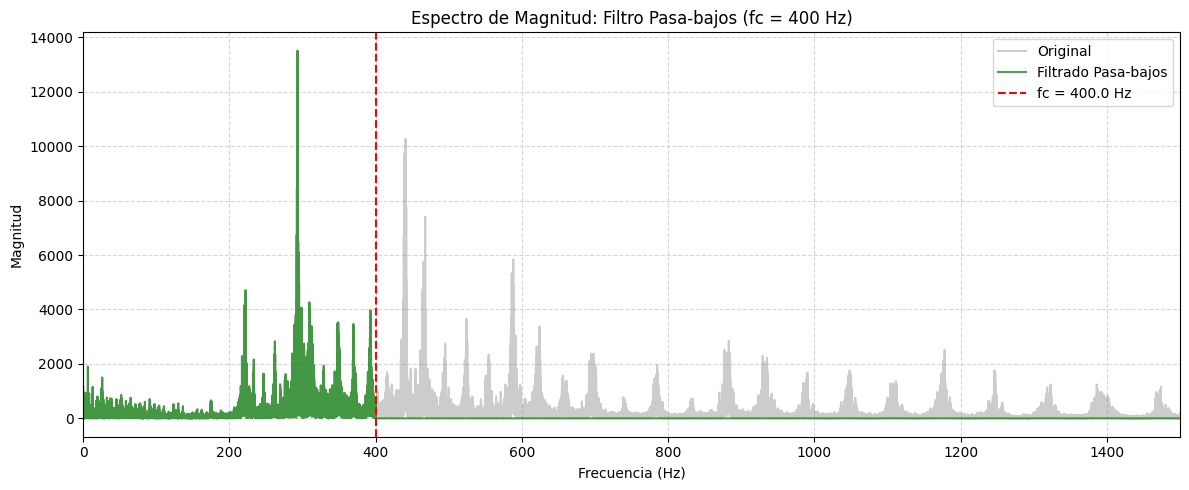

Audio guardado como 'audio_pasa_bajos.wav'


In [145]:
# Frecuencia de corte seleccionada
fc = 400.0

# Copia limpia de los coeficientes de Fourier
fft_lp = fft_vals.copy()

# Poner en cero los coeficientes con frecuencia > fc
fft_lp[fft_freqs > fc] = 0

# Reconstruir la señal en el dominio del tiempo
signal_lp = np.fft.irfft(fft_lp)

# Graficar espectro original vs. filtrado
plt.figure(figsize=(12, 5))
plt.plot(fft_freqs, magnitudes, color='gray', alpha=0.4, label='Original')
plt.plot(fft_freqs, np.abs(fft_lp), color='forestgreen', alpha=0.8, label='Filtrado Pasa-bajos')
plt.axvline(x=fc, color='red', linestyle='--', label=f'fc = {fc} Hz')
plt.title("Espectro de Magnitud: Filtro Pasa-bajos (fc = 400 Hz)", fontsize=12)
plt.xlabel("Frecuencia (Hz)", fontsize=10)
plt.ylabel("Magnitud", fontsize=10)
plt.xlim(0, 1500)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Guardar el audio resultante (escalando a int16 para mantener formato original)
signal_lp_int = np.clip(signal_lp * max_theoretical, -32768, 32767).astype(np.int16)
wavfile.write('audio_pasa_bajos.wav', samplerate, signal_lp_int)
print("Audio guardado como 'audio_pasa_bajos.wav'")

**Descripción de resultados (Filtro pasa-bajos):**
* **Espectro:** Se observa un corte abrupto de los coeficientes de Fourier a partir de los $400$ Hz. Toda la energía superior a este límite es suprimida.
* **Efecto Auditivo:** Al remover las frecuencias agudas ($440.99$ Hz, $467.65$ Hz, $588.17$ Hz) y sus armónicos superiores, el audio suena apagado, opaco y grave. Ha perdido todo el brillo y se asemeja a un sonido "subacuático" o reproducido detrás de una pared gruesa.

### 4. Filtro pasa-altos

Usando la misma frecuencia de corte $f_c = 400$ Hz, aplicamos un filtro pasa-altos. Esta vez ponemos en cero los coeficientes correspondientes a frecuencias menores a $f_c$, eliminando los tonos graves de la señal.

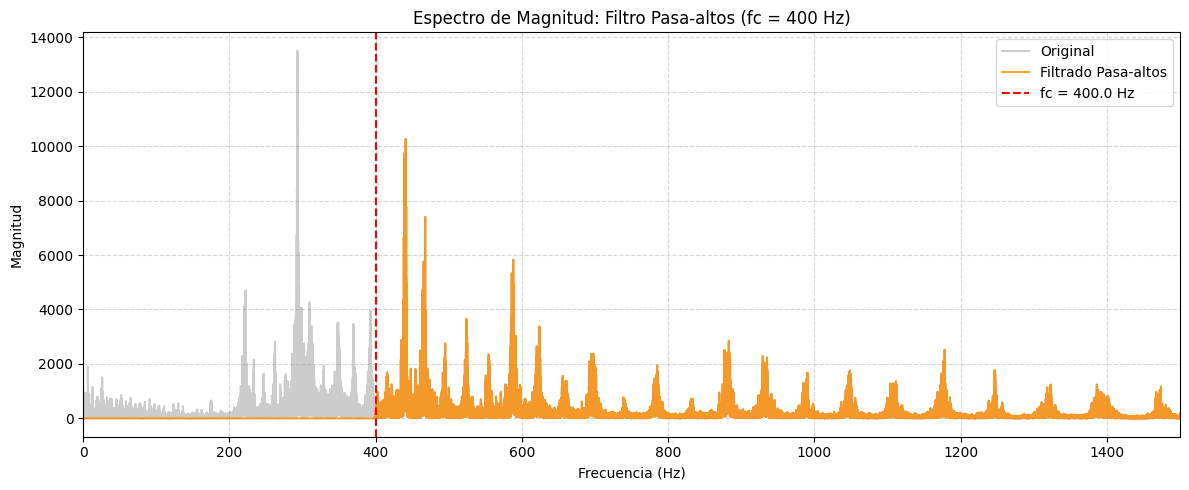

Audio guardado como 'audio_pasa_altos.wav'


In [146]:
# Copia limpia de los coeficientes de Fourier
fft_hp = fft_vals.copy()

# Poner en cero los coeficientes con frecuencia < fc
fft_hp[fft_freqs < fc] = 0

# Reconstruir la señal en el dominio del tiempo
signal_hp = np.fft.irfft(fft_hp)

# Graficar espectro original vs. filtrado
plt.figure(figsize=(12, 5))
plt.plot(fft_freqs, magnitudes, color='gray', alpha=0.4, label='Original')
plt.plot(fft_freqs, np.abs(fft_hp), color='darkorange', alpha=0.8, label='Filtrado Pasa-altos')
plt.axvline(x=fc, color='red', linestyle='--', label=f'fc = {fc} Hz')
plt.title("Espectro de Magnitud: Filtro Pasa-altos (fc = 400 Hz)", fontsize=12)
plt.xlabel("Frecuencia (Hz)", fontsize=10)
plt.ylabel("Magnitud", fontsize=10)
plt.xlim(0, 1500)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Guardar el audio resultante
signal_hp_int = np.clip(signal_hp * max_theoretical, -32768, 32767).astype(np.int16)
wavfile.write('audio_pasa_altos.wav', samplerate, signal_hp_int)
print("Audio guardado como 'audio_pasa_altos.wav'")

**Descripción de resultados (Filtro pasa-altos):**
* **Espectro:** La energía por debajo de $400$ Hz ha sido eliminada por completo. Esto remueve la nota más potente en $293.20$ Hz y la de $222.12$ Hz.
* **Efecto Auditivo:** El sonido resultante es muy agudo, brillante y "delgado" (metálico). Pierde toda su base o cuerpo, sonando similar a una radio antigua de baja calidad o al altavoz de un teléfono móvil antiguo, ya que carece por completo de componentes de frecuencia baja.

### 5. Filtro elimina-banda (band-stop)

Para este filtro, decidimos remover selectivamente la nota más dominante de la melodía ($293.20$ Hz). Con este fin, definimos una banda a eliminar en el rango $[f_{low}, f_{high}] = [280, 310]$ Hz. El objetivo es silenciar esa nota musical específica, pero manteniendo el resto de las frecuencias (graves menores a $280$ Hz y agudas mayores a $310$ Hz) sin alteraciones.

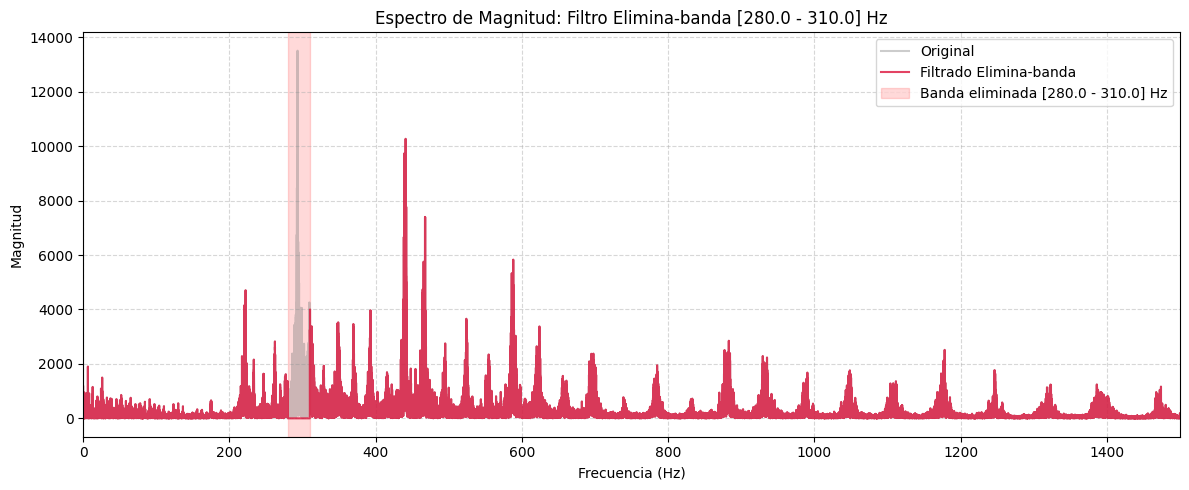

Audio guardado como 'audio_elimina_banda.wav'


In [147]:
# Límites de la banda a eliminar
flow = 280.0
fhigh = 310.0

# Copia limpia de los coeficientes de Fourier
fft_bs = fft_vals.copy()

# Poner en cero los coeficientes en el rango [flow, fhigh]
fft_bs[(fft_freqs >= flow) & (fft_freqs <= fhigh)] = 0

# Reconstruir la señal en el dominio del tiempo
signal_bs = np.fft.irfft(fft_bs)

# Graficar espectro original vs. filtrado
plt.figure(figsize=(12, 5))
plt.plot(fft_freqs, magnitudes, color='gray', alpha=0.4, label='Original')
plt.plot(fft_freqs, np.abs(fft_bs), color='crimson', alpha=0.8, label='Filtrado Elimina-banda')
plt.axvspan(flow, fhigh, color='red', alpha=0.15, label=f'Banda eliminada [{flow} - {fhigh}] Hz')
plt.title(f"Espectro de Magnitud: Filtro Elimina-banda [{flow} - {fhigh}] Hz", fontsize=12)
plt.xlabel("Frecuencia (Hz)", fontsize=10)
plt.ylabel("Magnitud", fontsize=10)
plt.xlim(0, 1500)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Guardar el audio resultante
signal_bs_int = np.clip(signal_bs * max_theoretical, -32768, 32767).astype(np.int16)
wavfile.write('audio_elimina_banda.wav', samplerate, signal_bs_int)
print("Audio guardado como 'audio_elimina_banda.wav'")

**Descripción de resultados (Filtro elimina-banda):**
* **Espectro:** Se observa una "zanja" o hueco perfecto en el rango $[280, 310]$ Hz. El resto del espectro permanece intacto.
* **Efecto Auditivo:** A diferencia de los filtros anteriores, este conserva tanto el brillo de los agudos como la base de los graves. Sin embargo, se percibe un "vacío armónico" o un agujero en la melodía debido a la ausencia de la nota principal en $293.20$ Hz. Modifica la armonía general de la melodía sin oscurecer ni adelgazar todo el audio globalmente.

### 6. FFT en intervalos



In [152]:
# funcion auxiliar
def amplit_heapmap_on(signal, l: int):
    '''
        graficar el espectrograma de `signal` dividida en intervalos de tamano `l`
    '''
    # agregar 0 para que pueda dividir por `l`
    pad_size = l - (len(signal) % l)
    padded_signal = np.pad(signal, (0, pad_size), constant_values=0)

    # convertir en matriz
    signal_matrix = padded_signal.reshape(-1, l)
    signal_matrix.shape

    # FFT
    fft_matrix = np.fft.rfft(signal_matrix)
    amplit_matrix = np.abs(fft_matrix)
    amplit_matrix.shape

    # magnitud en escala log
    masked_amplit = np.where(amplit_matrix == 0, np.nan, amplit_matrix) # ignorar ceros
    log_amplitude_matrix = np.log10(masked_amplit)
    plot_data = log_amplitude_matrix.T #  frecuencia x tiempo

    # Graficar heapmap
    plt.figure(figsize=(10, 6))
    im = plt.imshow(plot_data, aspect='auto', origin='lower', cmap='viridis')

    plt.title("Espectrograma (Heatmap en escala log)")
    plt.xlabel("Tiempo (indice)")
    plt.ylabel("Frecuencia")

    # colorbar
    cbar = plt.colorbar(im)
    cbar.set_label("Amplitude (log_10)")

    plt.tight_layout()
    plt.show()

Dividimos la señal en intervalos continuos de longitud ℓ = $\sqrt{\text{\#SIGNAL}} \approx 1770 $. Luego calculamos la FFT para cada intervalo.

1770


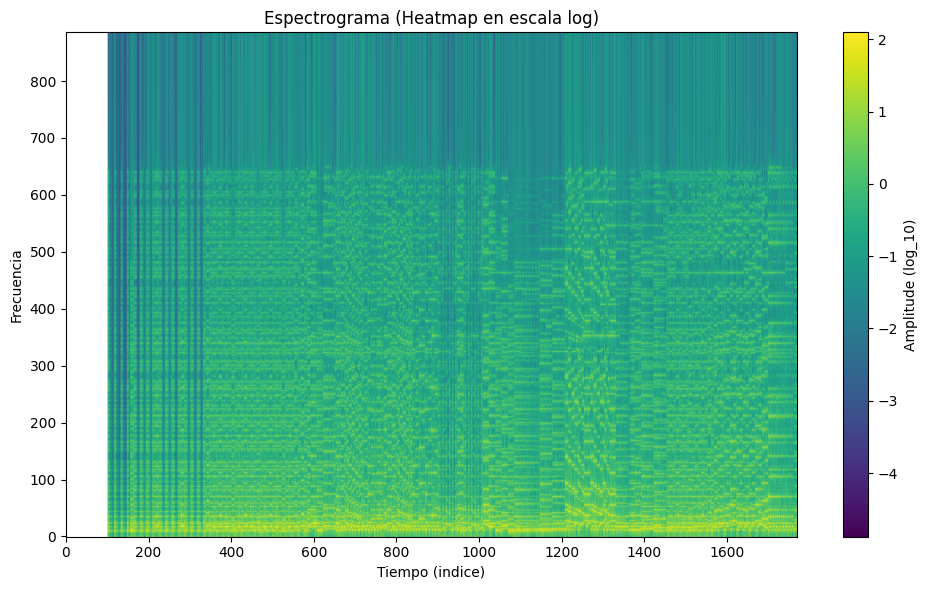

In [149]:
l1 = round((len(signal_norm)) ** (1/2))
print(l1)
amplit_heapmap_on(signal_norm, l1)

Observamos que entre el tiempo 0 y aproximadamente el 150, no hay informacion de la amplitud de todas las frecuencias, lo que indica que no había sonido durante ese periodo, consistente con el archivo.

Luego, observamos que la amplitud de baja frecuencia se mantenía en un nivel alto, lo que indica la presencia de un componente continuo de baja frecuencia en el audio. Ademas, los componentes variables de alta frecuencia correspondían a la melodía principal que escuchamos.

Cuando l es pequeño, la precisión temporal aumenta, pero el rango de frecuencias disminuye. Cuando l es grande, la precisión temporal disminuye, pero el rango de frecuencias aumenta. Esto se corresponde con el principio de incertidumbre.

Verificamos:

Dividimos con $l = 256$

256


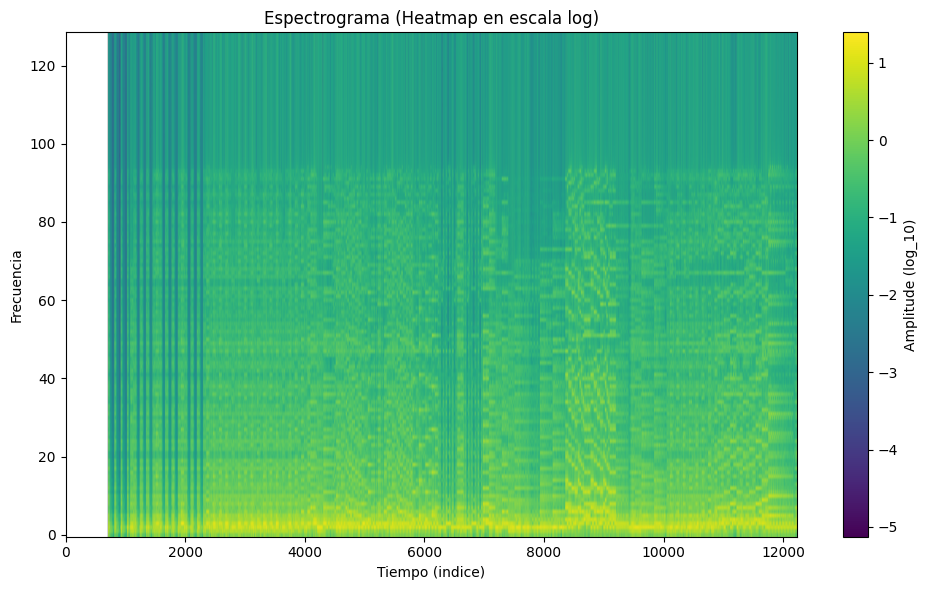

In [150]:
l_baja = 256
print(l_baja)
amplit_heapmap_on(signal_norm, l_baja)

y con $l = 8192$

8192


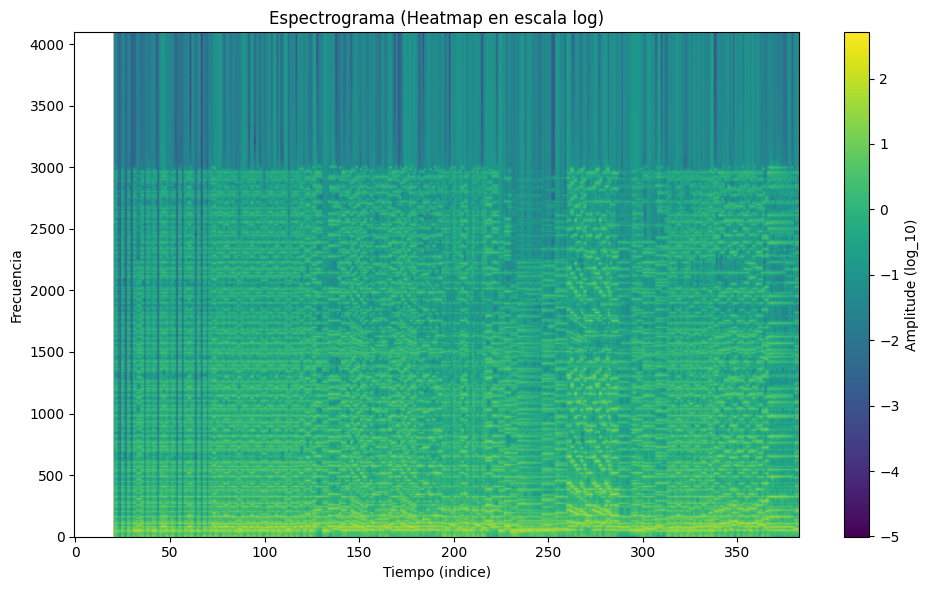

In [151]:
l_baja = 8192
print(l_baja)
amplit_heapmap_on(signal_norm, l_baja)

Se nota cuando $l = 256$ bajas, tenemos 12k+ indice de tiempo, pero solo aproximadamente 130 frecuencias distintas.

Luego cuando $l = 8192$ altas, tenemos solo aproximadamente 400 indice de tiempo, pero 4k+ frecuencias.